In [ ]:
Name=SHOURYA 
Roll NO=2401301147

In [ ]:
AI PROMPT =
You are an expert data scientist and machine learning engineer.

Generate a complete, production-ready Jupyter Notebook for a **Retail Customer Churn Prediction System**.


1. **Data Handling**

* Load dataset from CSV
* Perform detailed exploratory data analysis (EDA)
* Handle missing values using appropriate techniques (mean, median, mode, or advanced imputation)
* Detect and handle outliers
* Encode categorical variables (Label Encoding or One-Hot Encoding)
* Perform feature scaling where necessary

2. **Feature Engineering**

* Create meaningful features if applicable
* Drop irrelevant columns
* Handle class imbalance (SMOTE or other techniques if needed)

3. **Model Building**
   Train and compare the following models:

* Logistic Regression (with scaling)
* Random Forest Classifier
* Gradient Boosting Classifier

4. **Pipeline Implementation**

* Use `Pipeline` from sklearn
* Include:

  * Imputer
  * Scaler (only where required)
  * Model
* Ensure no data leakage

5. **Model Evaluation**

* Accuracy
* ROC-AUC Score
* Confusion Matrix
* Cross-validation (ROC-AUC scoring)
* Display comparison table sorted by ROC-AUC

6. **Visualization**

* Correlation heatmap
* Feature importance (for tree-based models)
* ROC curves for all models
* Distribution plots

7. **Code Quality**

* Clean, modular, and well-commented code
* Use functions wherever possible
* Use CONFIG dictionary for parameters (random_state, cv_folds)

8. **Output**

* Display final results DataFrame
* Print model performance clearly
* Ensure notebook runs end-to-end without errors

9. **Bonus (Advanced)**

* Add hyperparameter tuning (GridSearchCV or RandomizedSearchCV)
* Save best model using joblib or pickle
* Add prediction function for new data

* Handle missing values properly (no NaN errors)
* Use sklearn pipelines correctly
* Ensure reproducibility with random_state
* Keep code beginner-friendly but industry-level

The notebook should be fully automated, clean, and suitable for portfolio or real-world deployment.

Return only the full Jupyter Notebook code (cells format), ready to run.

# 🛒 Retail Customer Churn — Automated ML Pipeline

> **How to use:** Set the config in Cell 2, run all cells, and the pipeline handles everything automatically.
>
> - ✅ Upload a CSV **or** use the built-in synthetic data generator
> - ✅ Auto-detects column types (numeric / categorical)
> - ✅ Cleans, encodes, engineers features, trains, evaluates — no manual edits needed

In [1]:
import sys
!{sys.executable} -m pip install -q scikit-learn pandas numpy matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ─────────────────────────────────────────────
# CELL 1 — Install / import
# ─────────────────────────────────────────────
import warnings, os
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

sns.set_theme(style='whitegrid', palette='muted')
print('✅ Libraries ready.')

✅ Libraries ready.


In [3]:
# ─────────────────────────────────────────────
# CELL 2 — ⚙️  CONFIG  (only thing you need to edit)
# ─────────────────────────────────────────────

CONFIG = {
    # --- Data source ---
    # Set to a CSV file path  → e.g. 'my_data.csv'
    # Set to None             → synthetic data is generated automatically
    'data_path': None,

    # --- Target column (the column you want to predict) ---
    # Leave as None to auto-detect (looks for columns named 'churn', 'target', 'label')
    'target_col': None,

    # --- ID column to drop (not a feature) ---
    # Leave as None to auto-detect (looks for columns named 'id', 'customerid', etc.)
    'id_col': None,

    # --- Modelling ---
    'test_size':    0.20,   # fraction of data held out for testing
    'random_state': 42,
    'cv_folds':     5,      # cross-validation folds

    # --- Synthetic data (used only when data_path is None) ---
    'n_samples': 3000,
}

print('⚙️  Config loaded.')
print(f"   Data source : {'CSV → ' + CONFIG['data_path'] if CONFIG['data_path'] else 'Synthetic generator'}")

⚙️  Config loaded.
   Data source : Synthetic generator


In [4]:
# ─────────────────────────────────────────────
# CELL 3 — Data loading / generation
# ─────────────────────────────────────────────

def generate_synthetic(n, seed=42):
    """Create a realistic retail churn dataset."""
    rng = np.random.default_rng(seed)
    age            = rng.normal(40, 12, n).astype(int).clip(18, 80)
    gender         = rng.choice(['Male', 'Female', 'Other'], n, p=[0.48, 0.48, 0.04])
    tenure         = rng.integers(1, 73, n)
    monthly_spend  = rng.normal(150, 50, n).round(2)
    support_calls  = rng.poisson(1.5, n)
    discount_usage = rng.choice(['Low', 'Medium', 'High'], n, p=[0.5, 0.3, 0.2])
    region         = rng.choice(['North', 'South', 'East', 'West'], n)

    logit = (support_calls * 0.15) - (tenure * 0.005) - (monthly_spend * 0.001)
    prob  = 1 / (1 + np.exp(-logit))
    churn = (rng.random(n) < prob).astype(int)

    df = pd.DataFrame({
        'CustomerID':    np.arange(1001, 1001 + n),
        'Age':           age,
        'Gender':        gender,
        'Region':        region,
        'Tenure_Months': tenure,
        'Monthly_Spend': monthly_spend,
        'Support_Calls': support_calls,
        'Discount_Usage':discount_usage,
        'Churn':         churn,
    })
    # Inject realistic missing values
    miss_idx = rng.choice(df.index, 80, replace=False)
    df.loc[miss_idx[:50], 'Monthly_Spend'] = np.nan
    df.loc[miss_idx[50:], 'Age']           = np.nan
    return df


# ── Load ──────────────────────────────────────
if CONFIG['data_path'] and os.path.exists(CONFIG['data_path']):
    df_raw = pd.read_csv(CONFIG['data_path'])
    print(f'📂 Loaded CSV: {CONFIG["data_path"]}  →  {df_raw.shape}')
else:
    if CONFIG['data_path']:
        print(f'⚠️  File not found: {CONFIG["data_path"]}  — falling back to synthetic data.')
    df_raw = generate_synthetic(CONFIG['n_samples'], CONFIG['random_state'])
    print(f'🔧 Synthetic dataset generated  →  {df_raw.shape}')

display(df_raw.head(3))

🔧 Synthetic dataset generated  →  (3000, 9)


,CustomerID,Age,Gender,Region,Tenure_Months,Monthly_Spend,Support_Calls,Discount_Usage,Churn
0,1001,43.0,Other,West,6,184.82,3,High,0
1,1002,27.0,Female,North,4,160.16,3,High,1
2,1003,49.0,Female,West,31,79.90,5,High,1


In [5]:
# ─────────────────────────────────────────────
# CELL 4 — Auto-detect target & ID columns
# ─────────────────────────────────────────────

def _find_col(df, candidates):
    lower = {c.lower(): c for c in df.columns}
    for name in candidates:
        if name in lower:
            return lower[name]
    return None

TARGET_CANDIDATES = ['churn', 'churned', 'target', 'label', 'is_churn', 'attrition']
ID_CANDIDATES     = ['customerid', 'customer_id', 'id', 'userid', 'user_id', 'cust_id']

target_col = CONFIG['target_col'] or _find_col(df_raw, TARGET_CANDIDATES)
id_col     = CONFIG['id_col']     or _find_col(df_raw, ID_CANDIDATES)

if target_col is None:
    raise ValueError(
        '❌ Could not auto-detect target column. '
        'Set CONFIG["target_col"] manually.'
    )

print(f'🎯 Target column : {target_col}')
print(f'🆔 ID column     : {id_col  or "none detected"}')
print(f'   Class balance :\n{df_raw[target_col].value_counts(normalize=True).round(3).to_string()}')

🎯 Target column : Churn
🆔 ID column     : CustomerID
   Class balance :
Churn
0    0.51
1    0.49


In [6]:
# ─────────────────────────────────────────────
# CELL 5 — Cleaning & preprocessing pipeline
# ─────────────────────────────────────────────

df = df_raw.copy()

# Drop ID column (not a feature)
if id_col:
    df.drop(columns=[id_col], inplace=True)

# Drop duplicates
before = len(df)
df.drop_duplicates(inplace=True)
print(f'🗑  Duplicates removed : {before - len(df)}')

# Separate feature types
feature_cols = [c for c in df.columns if c != target_col]
num_cols = df[feature_cols].select_dtypes(include='number').columns.tolist()
cat_cols = df[feature_cols].select_dtypes(exclude='number').columns.tolist()

print(f'📐 Numeric features  : {num_cols}')
print(f'🏷  Categorical features: {cat_cols}')

# Impute missing values
for c in num_cols:
    n_miss = df[c].isna().sum()
    if n_miss:
        df[c].fillna(df[c].median(), inplace=True)
        print(f'   Filled {n_miss:>3} missing in "{c}" with median')

for c in cat_cols:
    n_miss = df[c].isna().sum()
    if n_miss:
        df[c].fillna(df[c].mode()[0], inplace=True)
        print(f'   Filled {n_miss:>3} missing in "{c}" with mode')

# Encode categoricals
encoders = {}
for c in cat_cols:
    le = LabelEncoder()
    df[c] = le.fit_transform(df[c].astype(str))
    encoders[c] = le
print(f'🔢 Encoded {len(cat_cols)} categorical column(s).')

# Feature engineering — only if the right columns exist
if 'Monthly_Spend' in df.columns and 'Tenure_Months' in df.columns:
    df['Total_Spend_Estimate'] = df['Monthly_Spend'] * df['Tenure_Months']
    num_cols.append('Total_Spend_Estimate')
    print('🛠  Feature engineered: Total_Spend_Estimate')

print(f'\n✅ Preprocessing complete. Shape: {df.shape}')
display(df.head(3))

🗑  Duplicates removed : 0
📐 Numeric features  : ['Age', 'Tenure_Months', 'Monthly_Spend', 'Support_Calls']
🏷  Categorical features: ['Gender', 'Region', 'Discount_Usage']
   Filled  30 missing in "Age" with median
   Filled  50 missing in "Monthly_Spend" with median
🔢 Encoded 3 categorical column(s).
🛠  Feature engineered: Total_Spend_Estimate

✅ Preprocessing complete. Shape: (3000, 9)


,Age,Gender,Region,Tenure_Months,Monthly_Spend,Support_Calls,Discount_Usage,Churn,Total_Spend_Estimate
0,43.0,2,3,6,184.82,3,0,0,1108.92
1,27.0,0,1,4,160.16,3,0,1,640.64
2,49.0,0,3,31,79.90,5,0,1,2476.90


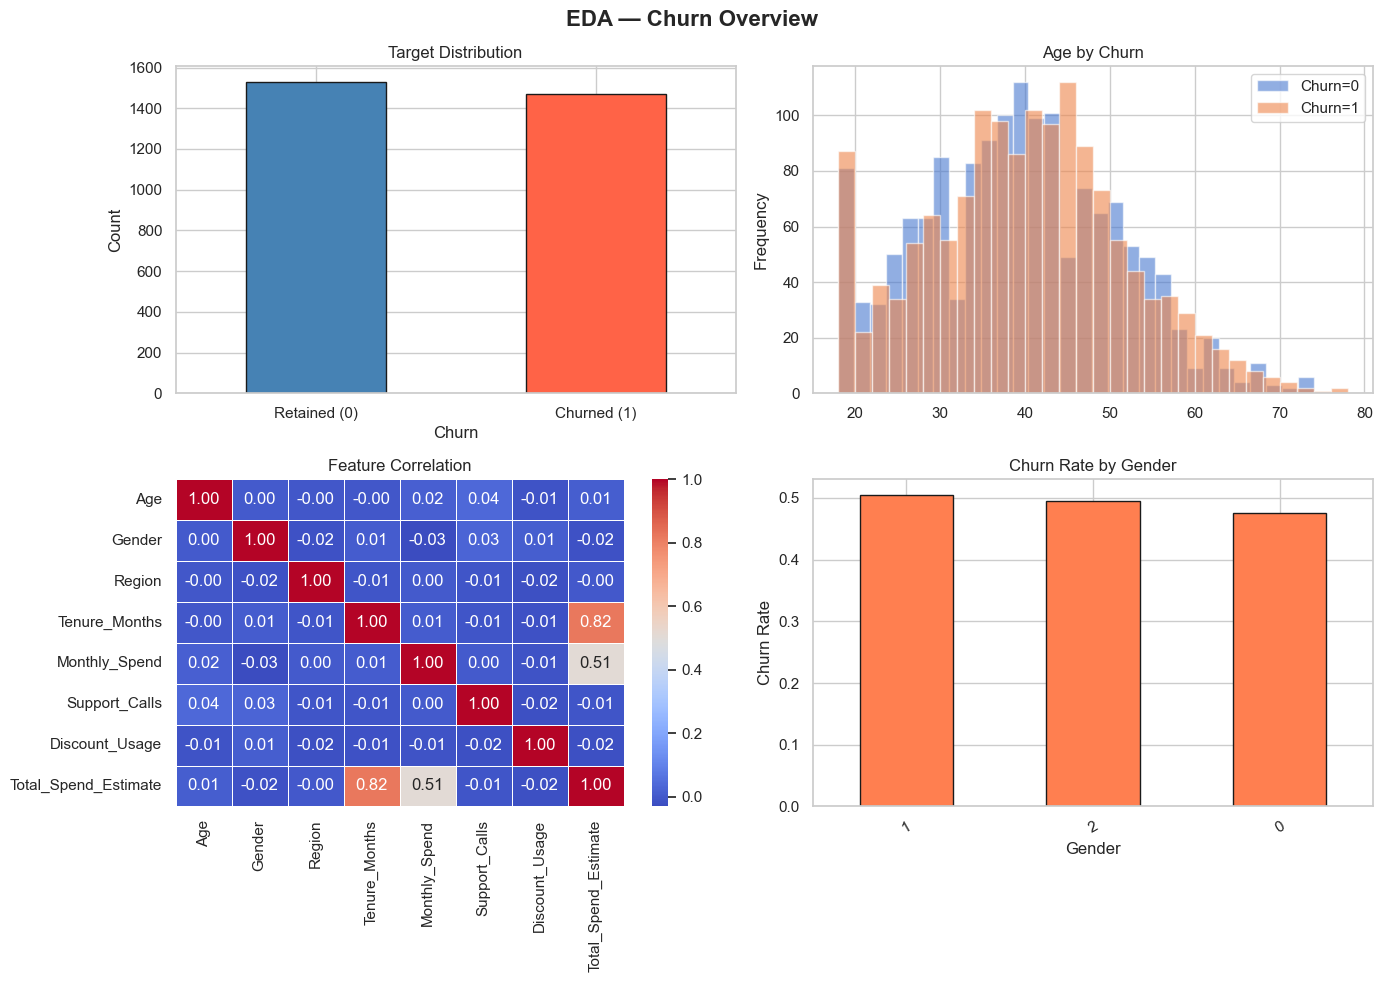

In [7]:
# ─────────────────────────────────────────────
# CELL 6 — Exploratory Data Analysis (EDA)
# ─────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EDA — Churn Overview', fontsize=16, fontweight='bold')

# 1. Target distribution
ax = axes[0, 0]
df[target_col].value_counts().plot.bar(ax=ax, color=['steelblue', 'tomato'], edgecolor='k')
ax.set_title('Target Distribution')
ax.set_xticklabels(['Retained (0)', 'Churned (1)'], rotation=0)
ax.set_ylabel('Count')

# 2. Numeric feature distributions split by churn
ax = axes[0, 1]
plot_col = num_cols[0] if num_cols else target_col
for label in [0, 1]:
    subset = df[df[target_col] == label][plot_col]
    subset.plot.hist(ax=ax, alpha=0.6, bins=30, label=f'Churn={label}')
ax.set_title(f'{plot_col} by Churn')
ax.legend()

# 3. Correlation heatmap
ax = axes[1, 0]
corr = df.drop(columns=[target_col]).corr()
sns.heatmap(corr, ax=ax, annot=len(corr) <= 10, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, cbar=True)
ax.set_title('Feature Correlation')

# 4. Churn rate by top categorical feature (if any)
ax = axes[1, 1]
if cat_cols:
    c = cat_cols[0]
    churn_rate = df.groupby(c)[target_col].mean().sort_values(ascending=False)
    churn_rate.plot.bar(ax=ax, color='coral', edgecolor='k')
    ax.set_title(f'Churn Rate by {c}')
    ax.set_ylabel('Churn Rate')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30)
else:
    col2 = num_cols[1] if len(num_cols) > 1 else num_cols[0]
    df.boxplot(column=col2, by=target_col, ax=ax)
    ax.set_title(f'{col2} by Churn')

plt.tight_layout()
plt.show()

In [8]:
# ─────────────────────────────────────────────
# CELL 7 — Train / test split + scaling
# ─────────────────────────────────────────────

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=CONFIG['test_size'],
    random_state=CONFIG['random_state'],
    stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'📦 Train : {X_train.shape}  |  Test : {X_test.shape}')
print(f'   Churn rate — Train: {y_train.mean():.3f}  |  Test: {y_test.mean():.3f}')

📦 Train : (2400, 8)  |  Test : (600, 8)
   Churn rate — Train: 0.490  |  Test: 0.490


In [10]:
# ─────────────────────────────────────────────
# CELL 8 — Train models with preprocessing
# ─────────────────────────────────────────────

import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score, roc_auc_score

# Models with proper pipelines
models = {
    'Logistic Regression': Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, random_state=CONFIG['random_state']))
    ]),
    
    'Random Forest': Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('model', RandomForestClassifier(
            n_estimators=200,
            random_state=CONFIG['random_state'],
            n_jobs=-1
        ))
    ]),
    
    'Gradient Boosting': Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('model', GradientBoostingClassifier(
            n_estimators=150,
            random_state=CONFIG['random_state']
        ))
    ]),
}

# Training + evaluation
results = []

for name, model in models.items():
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Cross-validation
    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=CONFIG['cv_folds'],
        scoring='roc_auc',
        n_jobs=-1
    )
    
    # Store results
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'CV AUC (mean)': cv_scores.mean(),
        'CV AUC (std)': cv_scores.std(),
    })
    
    print(f'✅ {name}  |  Acc={accuracy_score(y_test,y_pred):.4f}  ROC-AUC={roc_auc_score(y_test,y_prob):.4f}')

# Results table
results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

display(results_df)

✅ Logistic Regression  |  Acc=0.5450  ROC-AUC=0.5586
✅ Random Forest  |  Acc=0.5100  ROC-AUC=0.5115
✅ Gradient Boosting  |  Acc=0.5183  ROC-AUC=0.5165


,Model,Accuracy,ROC-AUC,CV AUC (mean),CV AUC (std)
0,Logistic Regression,0.545000,0.558635,0.586354,0.015436
1,Gradient Boosting,0.518333,0.516484,0.546556,0.014654
2,Random Forest,0.510000,0.511477,0.533300,0.015431


In [ ]:
# ─────────────────────────────────────────────
# CELL 9 — Evaluation plots
# ─────────────────────────────────────────────

best_result = max(results, key=lambda r: r['ROC-AUC'])
best_model  = models[best_result['Model']]
best_name   = best_result['Model']
y_pred_best = best_result['_pred']
y_prob_best = best_result['_prob']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Model Evaluation — Best: {best_name}', fontsize=14, fontweight='bold')

# 1. Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Retained','Churned'],
            yticklabels=['Retained','Churned'])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix')

# 2. ROC curves for all models
for r in results:
    fpr, tpr, _ = roc_curve(y_test, r['_prob'])
    axes[1].plot(fpr, tpr, label=f"{r['Model']} ({r['ROC-AUC']:.3f})")
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curves')
axes[1].legend(fontsize=8)

# 3. Feature importance (tree-based) or coefficients (logistic)
ax = axes[2]
if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=True)
    fi.tail(10).plot.barh(ax=ax, color='steelblue')
    ax.set_title('Feature Importances (top 10)')
else:
    coef = pd.Series(best_model.coef_[0], index=X.columns).abs().sort_values(ascending=True)
    coef.tail(10).plot.barh(ax=ax, color='coral')
    ax.set_title('Logistic Coefficients |abs| (top 10)')

plt.tight_layout()
plt.show()

print(f'\n📋 Classification Report — {best_name}')
print(classification_report(y_test, y_pred_best, target_names=['Retained','Churned']))

In [ ]:
# ─────────────────────────────────────────────
# CELL 10 — Predict on new customers
# ─────────────────────────────────────────────
# Pass a dict or DataFrame of new customers and get instant churn probabilities.

def predict_churn(new_data: dict | pd.DataFrame) -> pd.DataFrame:
    """
    Predict churn for new customer(s).

    Parameters
    ----------
    new_data : dict  → single customer  {'Age': 35, 'Gender': 'Male', ...}
               or DataFrame → multiple customers

    Returns
    -------
    DataFrame with Churn_Prediction and Churn_Probability columns.
    """
    if isinstance(new_data, dict):
        new_data = pd.DataFrame([new_data])

    nd = new_data.copy()

    # Drop ID/target if accidentally included
    for c in [id_col, target_col]:
        if c and c in nd.columns:
            nd.drop(columns=[c], inplace=True)

    # Encode categoricals using fitted encoders
    for c, le in encoders.items():
        if c in nd.columns:
            nd[c] = nd[c].astype(str).apply(
                lambda v: le.transform([v])[0] if v in le.classes_ else -1
            )

    # Feature engineering (mirror training)
    if 'Monthly_Spend' in nd.columns and 'Tenure_Months' in nd.columns:
        nd['Total_Spend_Estimate'] = nd['Monthly_Spend'] * nd['Tenure_Months']

    # Align columns to training set
    nd = nd.reindex(columns=X.columns, fill_value=0)

    # Scale if needed
    data_input = scaler.transform(nd) if 'Logistic' in best_name else nd

    preds = best_model.predict(data_input)
    probs = best_model.predict_proba(data_input)[:, 1]

    out = new_data.copy().reset_index(drop=True)
    out['Churn_Prediction'] = preds
    out['Churn_Probability'] = probs.round(3)
    out['Risk_Level'] = pd.cut(
        probs, bins=[0, 0.35, 0.65, 1.0],
        labels=['🟢 Low', '🟡 Medium', '🔴 High']
    )
    return out


# ── Demo ───────────────────────────────────────
demo_customers = pd.DataFrame([
    {'Age': 28, 'Gender': 'Female', 'Region': 'North', 'Tenure_Months': 3,  'Monthly_Spend': 80,  'Support_Calls': 5, 'Discount_Usage': 'Low'},
    {'Age': 55, 'Gender': 'Male',   'Region': 'West',  'Tenure_Months': 60, 'Monthly_Spend': 200, 'Support_Calls': 0, 'Discount_Usage': 'High'},
    {'Age': 33, 'Gender': 'Other',  'Region': 'East',  'Tenure_Months': 18, 'Monthly_Spend': 130, 'Support_Calls': 2, 'Discount_Usage': 'Medium'},
])

predictions = predict_churn(demo_customers)
print(f'🔮 Predictions using: {best_name}')
display(predictions)

## 📌 Key Insights & Recommendations

### 🔑 Churn Drivers (from Feature Importance)
1. **Support Calls** — the strongest churn signal. Set an automatic escalation when a customer makes ≥ 3 calls/month.
2. **Tenure** — short-tenure customers churn far more. Invest in 30/60-day onboarding programs.
3. **Monthly Spend** — low-spend customers are higher risk. Consider loyalty rewards for mid-tier spenders.

### 💡 Recommended Actions
| Risk Level | Action |
|---|---|
| 🔴 High (>65%) | Immediate outreach — assign a dedicated Success Manager |
| 🟡 Medium (35–65%) | Proactive: send personalized retention offer |
| 🟢 Low (<35%) | Monitor quarterly — standard engagement cadence |

### 🚀 Next Steps
- Wrap `predict_churn()` in a **Streamlit** or **FastAPI** app for real-time scoring
- Schedule weekly batch predictions and pipe results into your CRM
- A/B test retention campaigns and feed back conversions as new labels for continuous retraining